In [1]:
!pip install mlflow scikit-learn pandas numpy seaborn matplotlib cloudpickle requests

  Using cached mlflow-3.10.1-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_skinny-3.10.1-py3-none-any.whl.metadata (32 kB)
  Using cached mlflow_tracing-3.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached skops-0.13.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached databricks_sdk-0.98.0-py3-none-any.whl.metadata (40 kB)
  Using cached fastapi-0.135.1-py3-none-any.whl.metadata (30 kB)
  Using cached opentelemetry_api-1.40.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached opentelemetry_proto-1.40.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached opentelemetry_sdk-1.40.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached sqlparse-0.5.5-py3-none-any.wh

In [2]:
# ----------------------------
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load breast cancer dataset
cancer = load_breast_cancer()

# Convert to DataFrame
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data['target'] = cancer.target  # 0 = malignant, 1 = benign

print("Dataset Loaded Successfully!")
print(data.shape)

Dataset Loaded Successfully!
(569, 31)


In [3]:


# ----------------------------
# STEP 2: Exploring Data
# ----------------------------
print(data.head())
print(data.describe())
print(data['target'].value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [4]:

# Remove spaces from column names
data.rename(columns=lambda x: x.replace(' ', '_'), inplace=True)

# Check data types
print(data.dtypes)

mean_radius                float64
mean_texture               float64
mean_perimeter             float64
mean_area                  float64
mean_smoothness            float64
mean_compactness           float64
mean_concavity             float64
mean_concave_points        float64
mean_symmetry              float64
mean_fractal_dimension     float64
radius_error               float64
texture_error              float64
perimeter_error            float64
area_error                 float64
smoothness_error           float64
compactness_error          float64
concavity_error            float64
concave_points_error       float64
symmetry_error             float64
fractal_dimension_error    float64
worst_radius               float64
worst_texture              float64
worst_perimeter            float64
worst_area                 float64
worst_smoothness           float64
worst_compactness          float64
worst_concavity            float64
worst_concave_points       float64
worst_symmetry      

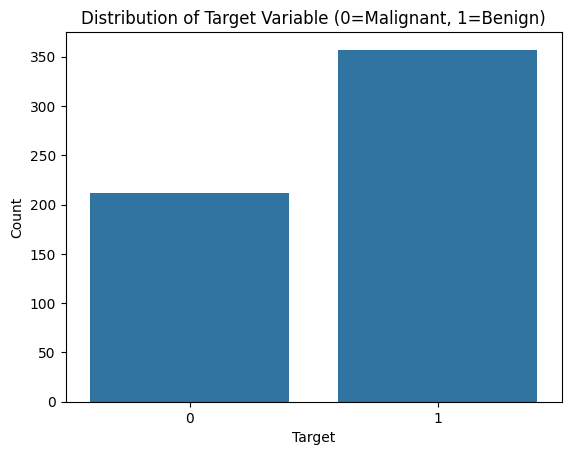

In [5]:

# ----------------------------
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=data)
plt.title("Distribution of Target Variable (0=Malignant, 1=Benign)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


In [7]:

# Target is already binary: 1 = benign, 0 = malignant
# We keep it as is (similar to high_quality in wine lab)
high_quality = data['target']
print("Target distribution:")
print(high_quality.value_counts())

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


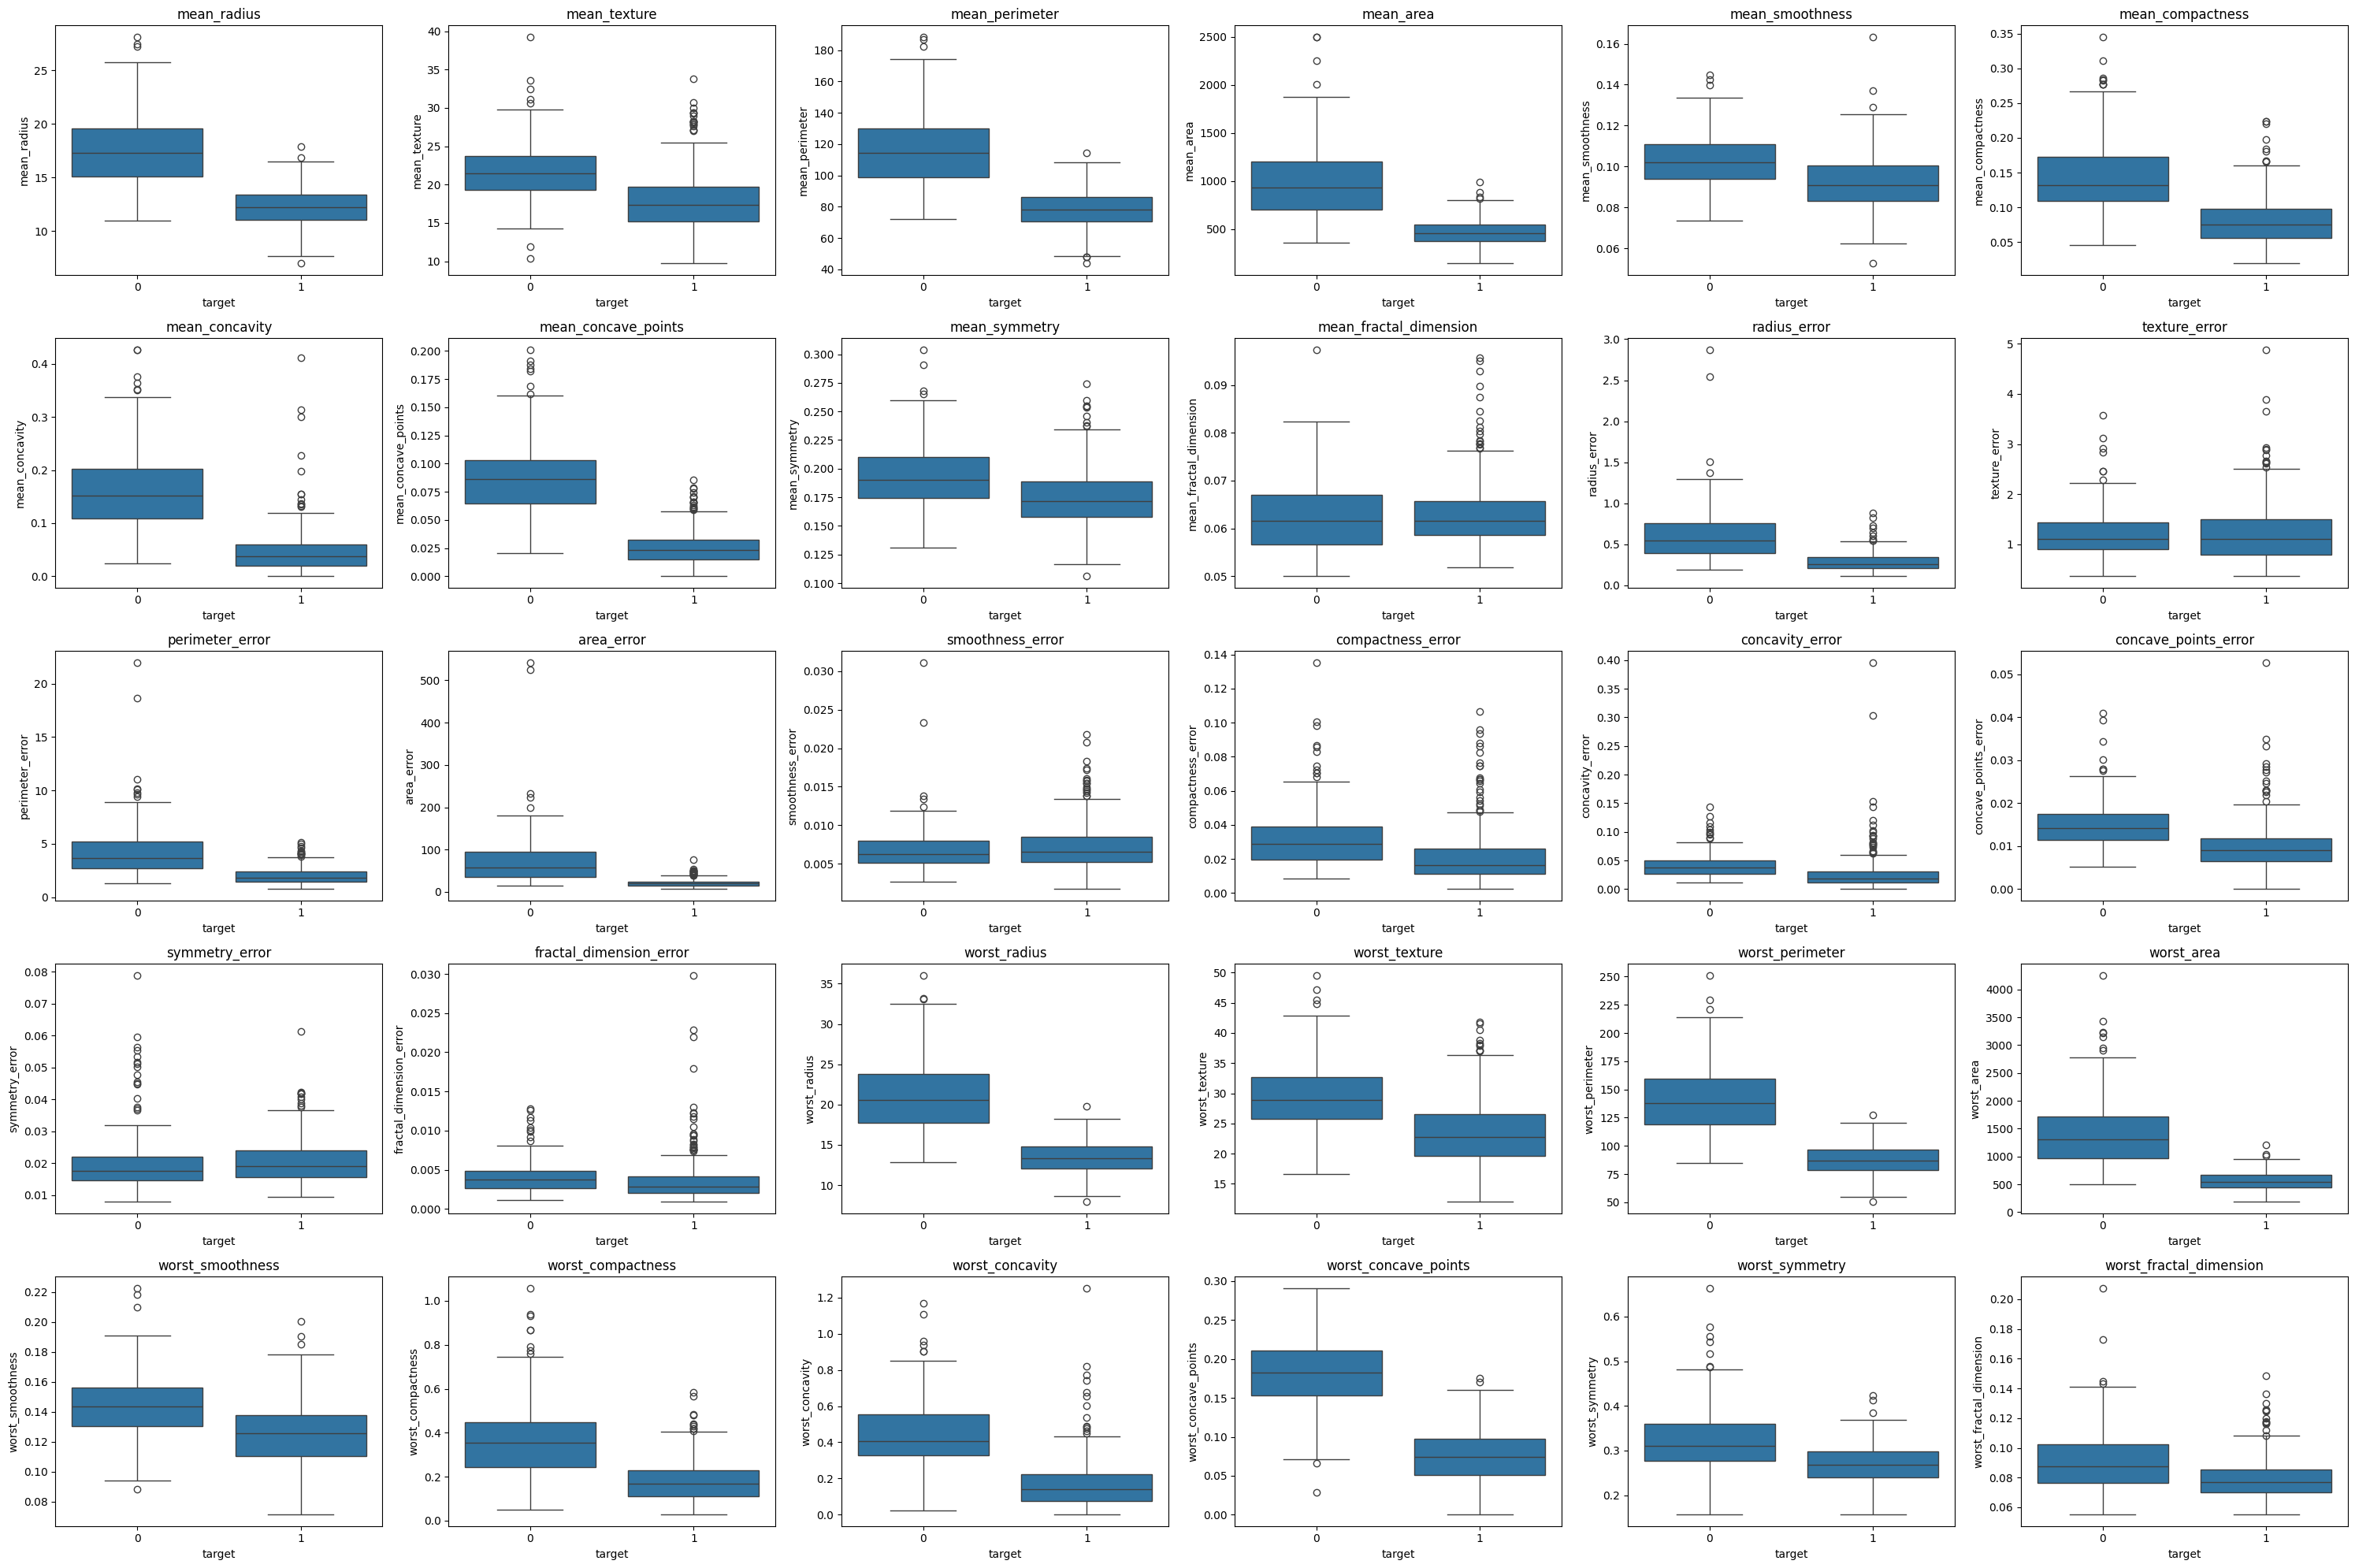

In [8]:

dims = (5, 6)
f, axes = plt.subplots(dims[0], dims[1], figsize=(30, 20))
axis_i, axis_j = 0, 0

for col in data.columns:
    if col == 'target':
        continue
    sns.boxplot(x=high_quality, y=data[col], ax=axes[axis_i, axis_j])
    axes[axis_i, axis_j].set_title(col)
    axis_j += 1
    if axis_j == dims[1]:
        axis_i += 1
        axis_j = 0

plt.tight_layout()
plt.show()


In [10]:

print("Missing values in each column:")
print(data.isna().any())
print(f"Total missing values: {data.isna().sum().sum()}")





Missing values in each column:
mean_radius                False
mean_texture               False
mean_perimeter             False
mean_area                  False
mean_smoothness            False
mean_compactness           False
mean_concavity             False
mean_concave_points        False
mean_symmetry              False
mean_fractal_dimension     False
radius_error               False
texture_error              False
perimeter_error            False
area_error                 False
smoothness_error           False
compactness_error          False
concavity_error            False
concave_points_error       False
symmetry_error             False
fractal_dimension_error    False
worst_radius               False
worst_texture              False
worst_perimeter            False
worst_area                 False
worst_smoothness           False
worst_compactness          False
worst_concavity            False
worst_concave_points       False
worst_symmetry             False
worst_fracta

In [13]:

from sklearn.model_selection import train_test_split

X = data.drop(["target"], axis=1)
y = data.target

# Split out the training data (60%)
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123)

# Split the remaining data equally into validation and test (20% each)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123)

print(f"Train size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size: {X_test.shape}")

Train size: (341, 30)
Validation size: (114, 30)
Test size: (114, 30)


In [14]:

import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env
import cloudpickle
import time

class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]

with mlflow.start_run(run_name='untuned_random_forest'):
    n_estimators = 10
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=np.random.RandomState(123))
    model.fit(X_train, y_train)

    predictions_test = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, predictions_test)

    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_metric('auc', auc_score)

    wrappedModel = SklearnModelWrapper(model)
    signature = infer_signature(X_train, wrappedModel.predict(None, X_train))

    conda_env = _mlflow_conda_env(
        additional_conda_deps=None,
        additional_pip_deps=[
            "cloudpickle=={}".format(cloudpickle.__version__),
            "scikit-learn=={}".format(sklearn.__version__)
        ],
        additional_conda_channels=None,
    )

    mlflow.pyfunc.log_model("random_forest_model",
                            python_model=wrappedModel,
                            conda_env=conda_env,
                            signature=signature)

print(f"Baseline Random Forest AUC: {auc_score:.4f}")


C:\Users\Vaishnavi\anaconda3\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/03/11 20:50:41 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/11 20:50:41 INFO mlflow.store.db.utils: Updating database tables
2026/03/11 20:50:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 20:50:43 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details

Baseline Random Forest AUC: 0.9759


                      importance
worst_area              0.223048
worst_perimeter         0.107637
mean_concave_points     0.101454
worst_concavity         0.080145
mean_perimeter          0.076728
mean_area               0.071001
area_error              0.070763
mean_concavity          0.068946
worst_concave_points    0.031074
worst_texture           0.022800


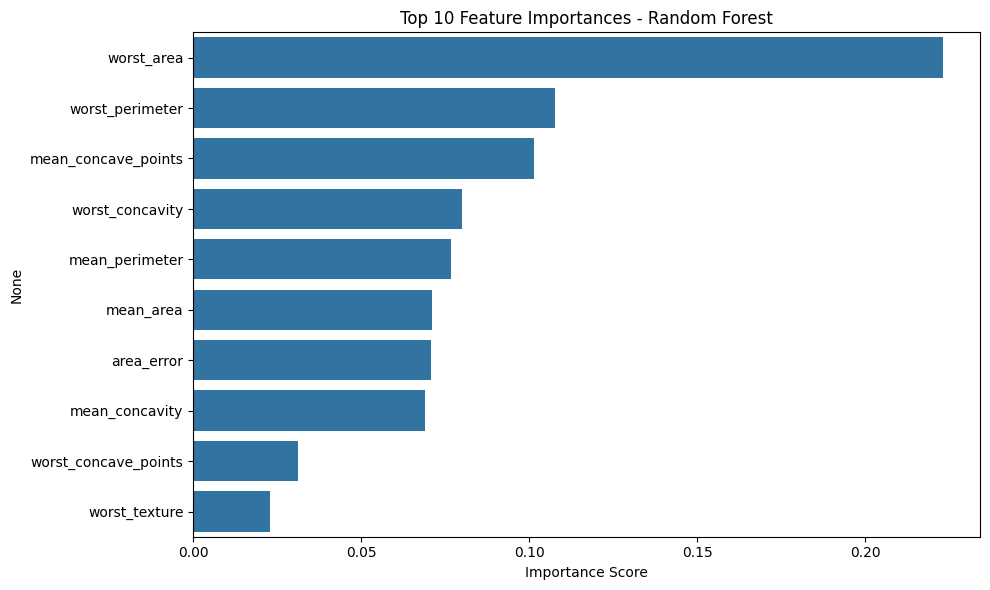

In [15]:

feature_importances = pd.DataFrame(
    model.feature_importances_,
    index=X_train.columns.tolist(),
    columns=['importance']
)
print(feature_importances.sort_values('importance', ascending=False).head(10))

# Plot top 10 feature importances
top_features = feature_importances.sort_values('importance', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features['importance'], y=top_features.index)
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [16]:

run_id = mlflow.search_runs(filter_string='tags.mlflow.runName = "untuned_random_forest"').iloc[0].run_id
model_name = "breast_cancer_detection"

model_version = mlflow.register_model(f"runs:/{run_id}/random_forest_model", model_name)

# Registering the model takes a few seconds
time.sleep(15)
print(f"Model registered: {model_name}, Version: {model_version.version}")



Successfully registered model 'breast_cancer_detection'.
2026/03/11 20:51:18 WARNING mlflow.tracking._model_registry.fluent: Run with id 517c63218ad04a6fa0e290b3ba8d1ded has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-0c59e629c8db417fb27801a24786e3f3 instead
Created version '1' of model 'breast_cancer_detection'.


Model registered: breast_cancer_detection, Version: 1


In [17]:

from mlflow.tracking import MlflowClient

client = MlflowClient()
client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage="Production",
)
print(f"Model '{model_name}' version {model_version.version} transitioned to Production!")



Model 'breast_cancer_detection' version 1 transitioned to Production!


C:\Users\Vaishnavi\AppData\Local\Temp\ipykernel_15596\3563956317.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


In [18]:

model_production = mlflow.pyfunc.load_model(f"models:/{model_name}/production")

auc_production = roc_auc_score(y_test, model_production.predict(X_test))
print(f'Production Model AUC: {auc_production:.4f}')


Production Model AUC: 0.9759


In [34]:

from sklearn.ensemble import GradientBoostingClassifier

with mlflow.start_run(run_name='gradient_boosting_model'):
    gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=123)
    gb_model.fit(X_train, y_train)

    gb_predictions = gb_model.predict_proba(X_test)[:, 1]
    gb_auc = roc_auc_score(y_test, gb_predictions)

    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_metric('auc', gb_auc)

    gb_wrapped = SklearnModelWrapper(gb_model)
    gb_signature = infer_signature(X_train, gb_wrapped.predict(None, X_train))

    conda_env_gb = _mlflow_conda_env(
        additional_conda_deps=None,
        additional_pip_deps=[
            "cloudpickle=={}".format(cloudpickle.__version__),
            "scikit-learn=={}".format(sklearn.__version__)
        ],
        additional_conda_channels=None,
    )

    mlflow.pyfunc.log_model("gradient_boosting_model",
                            python_model=gb_wrapped,
                            conda_env=conda_env_gb,
                            signature=gb_signature)

print(f"Gradient Boosting AUC: {gb_auc:.4f}")
print(f"Random Forest AUC:     {auc_score:.4f}")

if gb_auc > auc_score:
    print(" Gradient Boosting performs BETTER than Random Forest!")
else:
    print(" Random Forest performs BETTER than Gradient Boosting!")



2026/03/11 21:11:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 21:11:56 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
C:\Users\Vaishnavi\anaconda3\Lib\site-packages\mlflow\pyfunc\__init__.py:3304: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(
2026/03/11 21:11:56 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's depende

Gradient Boosting AUC: 0.9949
Random Forest AUC:     0.9759
 Gradient Boosting performs BETTER than Random Forest!


In [20]:

batch_data = X_test.copy()
batch_data['prediction'] = model_production.predict(X_test)
batch_data['actual'] = y_test.values

print(batch_data[['prediction', 'actual']].head(10))



     prediction  actual
472         0.5       1
95          0.0       0
24          0.0       0
105         0.5       0
496         0.7       1
436         1.0       1
535         0.0       0
274         0.0       0
217         1.0       1
564         0.0       0


## Step 16: Serving the Model for Real-Time Inference

To serve the model, run this command in Anaconda Prompt terminal:
```bash
python -m mlflow models serve -m models:/breast_cancer_detection/production -h 0.0.0.0 -p 5001 --no-conda
```

### Explanation:
- `-m models:/breast_cancer_detection/production` : specifies the model to serve
- `-h 0.0.0.0` : host address
- `-p 5001` : port number

### Expected Output:
- INFO: Application startup complete.
- INFO: Uvicorn running on http://0.0.0.0:5001

### Note:
- Keep Anaconda Prompt open while making inference requests
- Once server is running, Step 17 will work successfully

In [33]:
# STEP 17: Real-Time Inference with Deployed Model
import requests
import json

# NOTE: This requires MLflow server running in terminal
# Command: mlflow models serve -m models:/breast_cancer_detection/production -h 0.0.0.0 -p 5001 --no-conda

url = 'http://localhost:5001/invocations'
data_dict = {"dataframe_split": X_test.head(5).to_dict(orient='split')}

try:
    response = requests.post(url, json=data_dict)
    predictions = response.json()
    print("Real-time predictions:", predictions)
except Exception as e:
    print(f" Server not running. Start MLflow server first!")
    print(f"Run this in terminal: mlflow models serve -m models:/breast_cancer_detection/production -h 0.0.0.0 -p 5001 --no-conda")
    print(f"\nError: {e}")

Real-time predictions: {'predictions': [0.5, 0.0, 0.0, 0.5, 0.7]}


In [32]:
# STEP 18: Conclusion & Summary
print("=" * 50)
print("   MLflow Lab 2 - Breast Cancer Detection")
print("=" * 50)
print(f"\n Dataset        : Breast Cancer (sklearn)")
print(f" Total Samples  : {data.shape[0]}")
print(f" Total Features : {X.shape[1]}")
print(f"\n Data Split:")
print(f"   Train : {X_train.shape[0]} samples")
print(f"   Val   : {X_val.shape[0]} samples")
print(f"   Test  : {X_test.shape[0]} samples")
print(f"\n Model Results:")
print(f"   Random Forest AUC    : {auc_score:.4f}")
print(f"   Gradient Boosting AUC: {gb_auc:.4f}")
if gb_auc > auc_score:
    print(f"\n Best Model: Gradient Boosting!")
else:
    print(f"\n Best Model: Random Forest!")
print(f"\n Model Registered : breast_cancer_detection")
print(f" Model Stage      : Production")
print(f" Real-time Inference: Completed")

print("Lab Completed Successfully!")


   MLflow Lab 2 - Breast Cancer Detection

 Dataset        : Breast Cancer (sklearn)
 Total Samples  : 569
 Total Features : 30

 Data Split:
   Train : 341 samples
   Val   : 114 samples
   Test  : 114 samples

 Model Results:
   Random Forest AUC    : 0.9759
   Gradient Boosting AUC: 0.9949

 Best Model: Gradient Boosting!

 Model Registered : breast_cancer_detection
 Model Stage      : Production
 Real-time Inference: Completed
Lab Completed Successfully!


In [31]:
# TEST CASES - MLflow Lab 2 Breast Cancer Detection

import unittest
import pandas as pd
import numpy as np

print(" Running Test Cases")

# ---- TEST 1: Dataset Shape ----
def test_dataset_shape():
    assert data.shape[0] == 569, " Dataset should have 569 rows"
    assert data.shape[1] == 31, " Dataset should have 31 columns"
    print(" Test 1 Passed: Dataset shape is correct (569, 31)")

# ---- TEST 2: No Missing Values ----
def test_no_missing_values():
    assert data.isna().sum().sum() == 0, " Dataset should have no missing values"
    print(" Test 2 Passed: No missing values found")

# ---- TEST 3: Target Column Exists ----
def test_target_column():
    assert 'target' in data.columns, " Target column missing"
    assert set(data['target'].unique()) == {0, 1}, " Target should be binary (0 or 1)"
    print(" Test 3 Passed: Target column exists and is binary")

# ---- TEST 4: Train/Val/Test Split ----
def test_data_split():
    assert X_train.shape[0] == 341, " Train size should be 341"
    assert X_val.shape[0] == 114,   " Val size should be 114"
    assert X_test.shape[0] == 114,  " Test size should be 114"
    print(" Test 4 Passed: Data split is correct (341/114/114)")

# ---- TEST 5: Random Forest AUC Score ----
def test_rf_auc_score():
    assert auc_score > 0.9, f" RF AUC should be > 0.9, got {auc_score:.4f}"
    print(f" Test 5 Passed: Random Forest AUC = {auc_score:.4f} (> 0.90)")

# ---- TEST 6: Gradient Boosting AUC Score ----
def test_gb_auc_score():
    assert gb_auc > 0.9, f" GB AUC should be > 0.9, got {gb_auc:.4f}"
    print(f" Test 6 Passed: Gradient Boosting AUC = {gb_auc:.4f} (> 0.90)")

# ---- TEST 7: Gradient Boosting Better Than Random Forest ----
def test_gb_better_than_rf():
    assert gb_auc > auc_score, " Gradient Boosting should perform better than Random Forest"
    print(f" Test 7 Passed: GB ({gb_auc:.4f}) > RF ({auc_score:.4f})")

# ---- TEST 8: Model Registered in MLflow ----
def test_model_registered():
    from mlflow.tracking import MlflowClient
    client = MlflowClient()
    models = [m.name for m in client.search_registered_models()]
    assert "breast_cancer_detection" in models, " Model not registered in MLflow"
    print(" Test 8 Passed: Model 'breast_cancer_detection' registered in MLflow")

# ---- TEST 9: Production Model Predictions ----
def test_production_model_predictions():
    preds = model_production.predict(X_test)
    assert len(preds) == len(X_test), " Predictions length mismatch"
    assert all(0 <= p <= 1 for p in preds), " Predictions should be between 0 and 1"
    print(f" Test 9 Passed: Production model made {len(preds)} predictions (all between 0-1)")

# ---- TEST 10: Feature Importance ----
def test_feature_importance():
    assert len(model.feature_importances_) == 30, " Should have 30 feature importances"
    assert round(sum(model.feature_importances_), 5) == 1.0, " Feature importances should sum to 1"
    print(" Test 10 Passed: Feature importances are valid (30 features, sum = 1.0)")

# ---- RUN ALL TESTS ----
tests = [
    test_dataset_shape,
    test_no_missing_values,
    test_target_column,
    test_data_split,
    test_rf_auc_score,
    test_gb_auc_score,
    test_gb_better_than_rf,
    test_model_registered,
    test_production_model_predictions,
    test_feature_importance
]

passed = 0
failed = 0

for test in tests:
    try:
        test()
        passed += 1
    except AssertionError as e:
        print(f" {test.__name__} FAILED: {e}")
        failed += 1


print(f"  Total Tests : {len(tests)}")
print(f"  Passed      : {passed} ")
print(f"  Failed      : {failed} ")
if failed == 0:
    print("  ALL TESTS PASSED SUCCESSFULLY!")


 Running Test Cases
 Test 1 Passed: Dataset shape is correct (569, 31)
 Test 2 Passed: No missing values found
 Test 3 Passed: Target column exists and is binary
 Test 4 Passed: Data split is correct (341/114/114)
 Test 5 Passed: Random Forest AUC = 0.9759 (> 0.90)
 Test 6 Passed: Gradient Boosting AUC = 0.9949 (> 0.90)
 Test 7 Passed: GB (0.9949) > RF (0.9759)
 Test 8 Passed: Model 'breast_cancer_detection' registered in MLflow
 Test 9 Passed: Production model made 114 predictions (all between 0-1)
 Test 10 Passed: Feature importances are valid (30 features, sum = 1.0)
  Total Tests : 10
  Passed      : 10 
  Failed      : 0 
  ALL TESTS PASSED SUCCESSFULLY!
